<div class="alert alert-success"> 
        <h1 align="center" style="color:chocolate;">Academic Sucess Analysis
</h1>  
     
</div>

<table border="1" cellpadding="8">
    <tr>
        <th style="font-size: 18px;"><strong>Dataset Information</strong></th>
    </tr>
    <tr>
        <td style="font-size: 16px;">
            <strong>For what purpose was the dataset created?</strong><br>
            The dataset was created in a project that aims to contribute to the reduction of academic dropout and failure in higher education, by using machine learning techniques to identify students at risk at an early stage of their academic path, so that strategies to support them can be put into place.
        </td>
    </tr>
    <tr>
        <td style="font-size: 16px;">
            <strong>The dataset includes information known at the time of student enrollment – academic path, demographics, and social-economic factors.</strong>
        </td>
    </tr>
    <tr>
        <td style="font-size: 16px;">
            <strong>The problem is formulated as a three category classification task (dropout, enrolled, and graduate) at the end of the normal duration of the course.</strong>
        </td>
    </tr>
    <tr>
        <td style="font-size: 16px;">
            <strong>Who funded the creation of the dataset?</strong><br>
            This dataset is supported by program SATDAP - Capacitação da Administração Pública under grant POCI-05-5762-FSE-000191, Portugal.
        </td>
    </tr>
    <tr>
        <td style="font-size: 16px;">
            <strong>What do the instances in this dataset represent?</strong><br>
            Each instance is a student.
        </td>
    </tr>
    <tr>
        <td style="font-size: 16px;">
            <strong>Are there recommended data splits?</strong><br>
            The dataset was used, in our project, with a data split of 80% for training and 20% for test.
        </td>
    </tr>
    <tr>
        <td style="font-size: 16px;">
            <strong>Was there any data preprocessing performed?</strong><br>
            We performed a rigorous data preprocessing to handle data from anomalies, unexplainable outliers, and missing values.
        </td>
    </tr>
    <tr>
        <td style="font-size: 16px;">
            <strong>Has Missing Values?</strong><br>
            No
        </td>
    </tr>
</table>

In [ ]:
import pandas as pd

from sklearn.preprocessing import LabelEncoder, PolynomialFeatures, StandardScaler
import h2o
from h2o.automl import H2OAutoML
from itertools import combinations
from scipy.stats import gmean, hmean
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np
h2o.init()

<div class="alert alert-success"> 
        <h1 align="center" style="color:chocolate;">Enter the Data world
</h1>  
     
</div>

In [ ]:
df_train = pd.read_csv('/kaggle/input/playground-series-s4e6/train.csv')
df_test  = pd.read_csv('/kaggle/input/playground-series-s4e6/test.csv')
df_sub = pd.read_csv('/kaggle/input/playground-series-s4e6/sample_submission.csv')

<div class="alert alert-success"> 
        <h1 align="center" style="color:chocolate;">Metric of Evaluation for This Competition
</h1>  
     
</div>

   
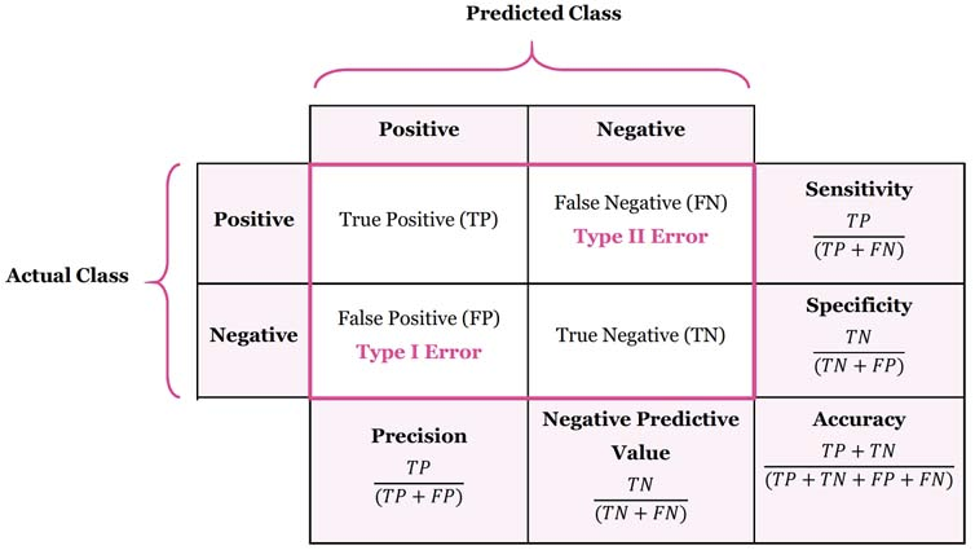

In [ ]:
df_train.shape

In [ ]:
df_test.shape

In [ ]:
df_sub.shape

In [ ]:
df_train.columns

In [ ]:
df_train.head()

🥅From first Look on Data what we observe🍱
<div style="background-color: #FFDDC1; padding: 10px;">⛈From Intial look for training data, df_train has over 😃38 columns and🦼 76518 rows .</div>	
<div style="background-color: #FFDDC1; padding: 10px;">🥨Test Data Information, we can say it has 🪔51012 rows and 🥓37 Columns .</div>	
<div style="background-color: #FFDDC1; padding: 10px;">🍭Submission file is were we can directly check and understand, what to classiy or predict, from the submission file, we can see 🏍Target is the required Classification task with 🥗51012 rows .</div>	
<div style="background-color: #FFDDC1; padding: 10px;"> In both df_train and df_test 🕺🏿id columns can be removed as it is just "id" which doesnot add any information </div>	

In [ ]:
df_train.drop(columns=['id'], inplace=True)
df_test.drop(columns=['id'], inplace=True)

In [ ]:
df_train.describe()

<div style="border-radius:10px; border:#DEB887 solid; padding: 15px; background-color: white; font-size:100%; text-align:left">

<h3 align="center"><font color='#DAA520'>💡 First Step in Understanding any data is to have basic descriptive stats check :</font></h3>
    
Marital status
Almost all entries fall into one category, with an average close to 1. The range extends to 6, indicating some variability but most are in the first category.
Application mode

The average application mode is 16, but there’s a wide spread with modes ranging from 1 to 53. Many students applied using mode 1, but there’s a lot of variety.
Application order

Most students applied as their first choice (median is 1), but it ranges up to 9. The average order is around 1.6.
Course

Course numbers are varied, ranging from 33 to 9991. The average course number is around 9000, indicating a high numerical designation system for courses.
Daytime/evening attendance

Most students attend during the daytime, with a mean of 0.92 (where 1 indicates daytime attendance). There’s very little variation.
Previous qualification

Most students have the same level of previous qualification, typically the first level, although some have qualifications up to level 43. The average The average order is around 1.6.
    
 Previous qualification (grade)

Grades for previous qualifications average around 132. The range is from 95 to 190, indicating some students have significantly higher previous grades.
Nacionality

Most students are from one nationality (median and mode are 1), but there are students from up to 109 different nationalities. The average nationality index is around 1.23, showing most students are from the primary nationality.
Mother's qualification

The educational level of mothers varies widely, with an average level of about 20. It ranges from 1 to 44, indicating diverse educational backgrounds.
    
Curricular Units For the curricular units in the first and second semesters (enrolled, evaluated, approved, credited, grade, and without evaluations):
    
    Count: All these categories have 76,518 entries.
Curricular units 1st sem (without evaluations): Most students have 0 units without evaluations.
Curricular units 2nd sem (credited): Very few students have credited units in the second semester.
Curricular units 2nd sem (enrolled): Students enroll in about 6 units on average in the second semester.
Curricular units 2nd sem (evaluations): Students undergo evaluations in about 7 units on average.
Curricular units 2nd sem (approved): On average, students get about 4 units approved.
Curricular units 2nd sem (grade): Average grade is around 9.6, with a standard deviation indicating a wide range of grades.
Curricular units 2nd sem (without evaluations): Most students do not have units without evaluations.
    
Economic Indicators
Unemployment rate: Average unemployment rate is around 11.5%.
Inflation rate: Average inflation rate is around 1.23%, with some periods of deflation (as low as -0.8%).
GDP: The average GDP growth rate is slightly negative (-0.08%), indicating slight economic contraction on average.
These statistics give you a comprehensive overview of the students’ demographics, academic background, and economic context.

<div class="alert alert-success"> 
        <h1 align="center" style="color:chocolate;">Lets Have a look at it Visually
</h1>  
     
</div>

In [ ]:
df_train_excluded = df_train.drop(columns=['Course'])
desc = df_train_excluded.describe()
desc_t = desc.transpose()
#desc_t = desc_t.drop(index='Course')
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 20))
for ax, metric in zip(axes.flatten(), desc_t.columns):
    ax.barh(desc_t.index, desc_t[metric], color='skyblue')
    ax.set_title(metric)
    ax.set_xlabel(metric)
    ax.set_ylabel('Columns')
plt.tight_layout()
plt.show()

<div class="alert alert-success"> 
        <h1 align="center" style="color:chocolate;">Some Facts About University ranking
</h1>  
     
</div>

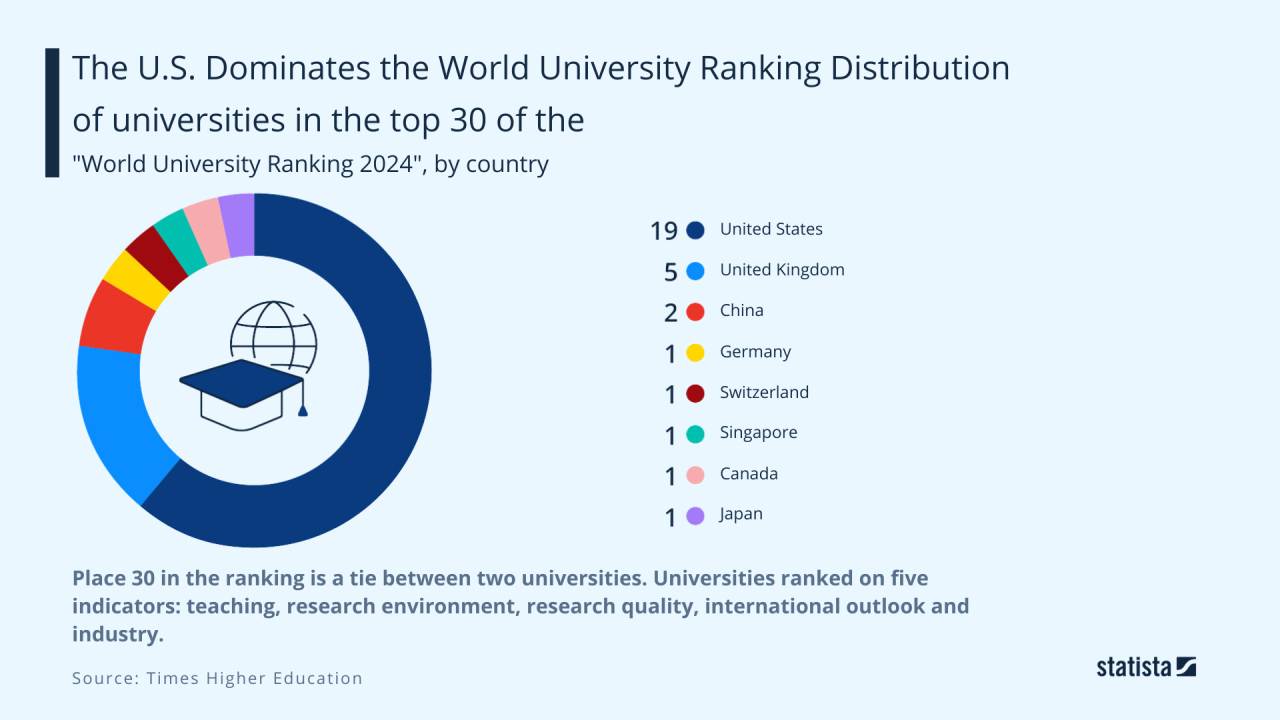

<div class="alert alert-success"> 
        <h1 align="center" style="color:chocolate;">Lets Check some Plots
</h1>  
     
</div>

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df_train['Target'] = label_encoder.fit_transform(df_train['Target'])

<div style="background-color: #d4edda; border-color: #c3e6cb; color: #155724; padding: 10px; margin-bottom: 20px;">
    <h1 style="text-align:center; font-size: 24px; color: chocolate;">Let's Check the Correlation Plot</h1>
    <p style="text-align:center; font-size: 18px;">This plot will show how each column correlates with the target variable. But before that, let's convert the target to numerical format.</p>
</div>

In [ ]:
import seaborn as sns
correlation_matrix = df_train.corr()
plt.figure(figsize=(20, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".1f", linewidths=0.5)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.title('Correlation Matrix')
plt.show() 

In [ ]:
correlation_matrix

In [ ]:
highly_correlated = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) >= 0.7:
            highly_correlated.append((correlation_matrix.index[i], correlation_matrix.columns[j]))

less_correlated = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) <= 0.3:
            less_correlated.append((correlation_matrix.index[i], correlation_matrix.columns[j]))

In [ ]:
target_column='Target'

In [ ]:
correlation_with_target = df_train.corr()[target_column].sort_values(ascending=False)
print("Correlation with Target:>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>")
print(correlation_with_target)

In [ ]:
plt.figure(figsize=(10, 8))
correlation_with_target.plot(kind='bar', color='skyblue')
plt.title('Correlation with Target Variable')
plt.xlabel('Features')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
!pip install Autoviz

🥅Automatic EDA using Autoviz🍱
<div style="background-color: #FFDDC1; padding: 10px;">🌭Just Like many autoomatic EDA tool, autoviz is one 🗯among them, We can see here summary and some plots to get direct understanding on data🎓.</div>	
<div style="background-color: #FFDDC1; padding: 10px;">🥨Lets See what we have in Autoviz.</div>	


In [ ]:
import autoviz
from autoviz.AutoViz_Class import AutoViz_Class
AV = AutoViz_Class()

In [ ]:
dftc = AV.AutoViz(df_train)

<div style="border-radius:10px; border:#DEB887 solid; padding: 15px; background-color: white; font-size:100%; text-align:left">

<h3 align="center"><font color='#DAA520'>💡What Do we see from Above Table lets summarize it :</font></h3>
    

<table>
  <tr>
    <th>Columns</th>
    <th>Observation about the data</th>
  </tr>
  <tr>
    <td>Data Types and Missing Values</td>
    <td>All columns are either <code>int64</code> or <code>float64</code>, with no missing values, indicating a complete dataset with consistent data types.</td>
  </tr>
  <tr>
    <td>Marital Status</td>
    <td>Majority of entries fall into one category, with significant outliers (6,329) beyond the expected value of 1, suggesting the need for outlier handling.</td>
  </tr>
  <tr>
    <td>Application Mode and Order</td>
    <td>Application mode shows no issues, while application order has 7,895 outliers beyond the expected range, indicating potential anomalies.</td>
  </tr>
  <tr>
    <td>Course</td>
    <td>Course column has 5,371 outliers beyond typical course numbers, suggesting a need for outlier handling.</td>
  </tr>
  <tr>
    <td>Daytime/Evening Attendance</td>
    <td>No issues found, with consistent values indicating clear categorization.</td>
  </tr>
  <tr>
    <td>Previous Qualification and Grade</td>
    <td>Previous qualification and grade contain outliers, requiring outlier handling.</td>
  </tr>
  <tr>
    <td>Nationality</td>
    <td>Contains 505 outliers beyond the expected value, indicating a need for outlier handling.</td>
  </tr>
  <tr>
    <td>Parental Qualifications and Occupations</td>
    <td>No issues with parental qualifications, but parental occupations show outliers and high correlation, suggesting potential redundancy.</td>
  </tr>
  <tr>
    <td>Admission Grade</td>
    <td>Contains outliers beyond the expected range, indicating a need for outlier handling.</td>
  </tr>
  <tr>
    <td>Age at Enrollment</td>
    <td>Contains outliers beyond the expected range, suggesting the need for outlier handling.</td>
  </tr>
  <tr>
    <td>Curricular Units (1st and 2nd Semester)</td>
    <td>Several columns contain significant outliers, with high correlations among some features, indicating potential redundancy.</td>
  </tr>
  <tr>
    <td>Economic Indicators</td>
    <td>No issues detected in unemployment rate, inflation rate, or GDP, indicating consistent economic data.</td>
  </tr>
</table>

<p style="font-family: 'Amiri', serif; font-size: 3rem; color: black; text-align: center; margin: 0; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.3); background-color: cyan; padding: 20px; border-radius: 20px; border: 7px solid #2ca02c; width: 95%;">
  <span style="font-weight: bold; color: #ff7f0e; animation: pulse 2s infinite;"></span>Featuring |
  <span style="font-style: italic; color: #2ca02c; animation: pulse 2s infinite;"> Engineering |</span> 

</p>

In [ ]:
df_train = pd.read_csv('/kaggle/input/interstellar-data/training.csv')
df_test  = pd.read_csv('/kaggle/input/interstellar-data/testing.csv')

In [ ]:
df_train.shape

In [ ]:
df_train.head()

In [ ]:
df_test.head()

In [ ]:
from scipy.stats import skew

def handle_skewed_columns(df):
    numerical_features = df.select_dtypes(include=[np.number])
    skewness = numerical_features.apply(lambda x: skew(x.dropna()))
    skewed_features = skewness[abs(skewness) > 1] 

    for col in skewed_features.index:
        if df[col].min() > -1: 
            df[f'{col}_log'] = np.log1p(df[col])
    return df

def add_interaction_features(df, columns):
    interaction_df = pd.DataFrame()
    for i in range(len(columns)):
        for j in range(i + 1, len(columns)):
            col1, col2 = columns[i], columns[j]
            interaction_df[f'{col1}_plus_{col2}'] = df[col1] + df[col2]
            interaction_df[f'{col1}_minus_{col2}'] = df[col1] - df[col2]
            interaction_df[f'{col1}_times_{col2}'] = df[col1] * df[col2]
            interaction_df[f'{col1}_div_{col2}'] = df[col1] / (df[col2] + 1e-6)  
    return interaction_df

def add_curriculum_interaction_features(df):
    df['Curriculum_interaction_1st_sem'] = df['Curricular units 1st sem (credited)'] * df['Curricular units 1st sem (enrolled)'] * df['Curricular units 1st sem (evaluations)'] * df['Curricular units 1st sem (approved)']
    df['Curriculum_interaction_2nd_sem'] = df['Curricular units 2nd sem (credited)'] * df['Curricular units 2nd sem (enrolled)'] * df['Curricular units 2nd sem (evaluations)'] * df['Curricular units 2nd sem (approved)']

def add_grade_interaction_features(df):
    df['Grade_interaction_1st_sem'] = df['Admission grade'] * df['Curricular units 1st sem (grade)']
    df['Grade_interaction_2nd_sem'] = df['Admission grade'] * df['Curricular units 2nd sem (grade)']

def add_age_interaction_features(df):
    df['Age_interaction'] = df['Age at enrollment'] * df['Previous qualification (grade)']  

def add_economic_interaction_features(df):
    df['Economic_interaction'] = df['Unemployment rate'] * df['Inflation rate'] * df['GDP']

def add_qualification_interaction_features(df):
    df['Qualification_interaction'] = df['Previous qualification'] * df['Admission grade']
    df['Course_interaction'] = df['Previous qualification'] * df['Course']
    
def add_occupation_interaction_features(df):
    df["Occupation_interaction"] = df["Mother's occupation"] * df["Father's occupation"]

def add_enrollment_evaluation_interaction_features(df):
    df['Enrollment_evaluation_interaction_1st_sem'] = df['Curricular units 1st sem (enrolled)'] * df['Curricular units 1st sem (evaluations)']
    df['Enrollment_evaluation_interaction_2nd_sem'] = df['Curricular units 2nd sem (enrolled)'] * df['Curricular units 2nd sem (evaluations)']

def add_gender_marital_interaction_features(df):
    df['Gender_marital_interaction'] = df['Gender'] * df['Marital status']

def add_tuition_scholarship_interaction_features(df):
    df['Tuition_scholarship_interaction'] = df['Tuition fees up to date'] * df['Scholarship holder']

def feature_engineer_train(df_train):    
    df_train = handle_skewed_columns(df_train)
    economic_cols = ['Unemployment rate', 'Inflation rate', 'GDP']
    relationship_cols = ["Mother's qualification"]    
    economic_interactions = add_interaction_features(df_train, economic_cols)
    relationship_interactions = add_interaction_features(df_train, relationship_cols)  
    df_train = pd.concat([df_train, economic_interactions, relationship_interactions], axis=1)
    add_curriculum_interaction_features(df_train)
    add_grade_interaction_features(df_train)
    add_age_interaction_features(df_train)
    add_economic_interaction_features(df_train)
    add_qualification_interaction_features(df_train)
    add_occupation_interaction_features(df_train)
    add_enrollment_evaluation_interaction_features(df_train)
    add_gender_marital_interaction_features(df_train)
    add_tuition_scholarship_interaction_features(df_train)
    return df_train

def feature_engineer_test(df_test):    
    df_test = handle_skewed_columns(df_test)
    economic_cols = ['Unemployment rate', 'Inflation rate', 'GDP']
    relationship_cols = ["Mother's qualification"]    
    economic_interactions = add_interaction_features(df_test, economic_cols)
    relationship_interactions = add_interaction_features(df_test, relationship_cols)  
    df_test = pd.concat([df_test, economic_interactions, relationship_interactions], axis=1)
    add_curriculum_interaction_features(df_test)
    add_grade_interaction_features(df_test)
    add_age_interaction_features(df_test)
    add_economic_interaction_features(df_test)
    add_qualification_interaction_features(df_test)
    add_occupation_interaction_features(df_test)
    add_enrollment_evaluation_interaction_features(df_test)
    add_gender_marital_interaction_features(df_test)
    add_tuition_scholarship_interaction_features(df_test)
    return df_test

In [ ]:
df_train = feature_engineer_train(df_train)
df_test = feature_engineer_test(df_test)

In [ ]:
df_train.head()

In [ ]:
def add_interaction_features(df):
    df['Application_mode_x_Application_order'] = df['Application mode'] * df['Application order']
    df['Course_x_Curricular_units_1st_sem_enrolled'] = df['Course'] * df['Curricular units 1st sem (enrolled)']
    df['Daytime_evening_attendance_x_Age_at_enrollment'] = df['Daytime/evening attendance'] * df['Age at enrollment']
    df['Previous_qualification_grade_x_Admission_grade'] = df['Previous qualification (grade)'] * df['Admission grade']
    df['Displaced_x_Curricular_units_1st_sem_approved'] = df['Displaced'] * df['Curricular units 1st sem (approved)']
    df['Scholarship_holder_x_Tuition_fees_up_to_date'] = df['Scholarship holder'] * df['Tuition fees up to date']
    df['Curricular_units_1st_sem_approved_x_Curricular_units_2nd_sem_approved'] = df['Curricular units 1st sem (approved)'] * df['Curricular units 2nd sem (approved)']
    df['Unemployment_rate_x_Inflation_rate'] = df['Unemployment rate'] * df['Inflation rate']
    return df

In [ ]:
df_train = add_interaction_features(df_train)
df_test = add_interaction_features(df_test)

In [ ]:
df_train.shape

In [ ]:
df_test.shape

In [ ]:
df_train.sample(4)

In [ ]:
df_train['Target']

In [ ]:
df_test.sample(4)

<p style="font-family: 'Amiri', serif; font-size: 3rem; color: black; text-align: center; margin: 0; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.3); background-color: black; padding: 20px; border-radius: 20px; border: 7px solid cyan; width: 95%;">
  <span style="font-weight: bold; color: blue; animation: pulse 2s infinite;">📉Let see How new Feature </span>
  <span style="font-style: italic; color: #2ca02c; animation: pulse 2s infinite;"> Impact  📊</span> 
</p>

In [ ]:
def find_duplicate_columns(df):
    """
    Find duplicate columns in a dataframe.
    
    Args:
    df (pd.DataFrame): The dataframe to check for duplicate columns.
    
    Returns:
    list: A list of lists, where each sublist contains the names of duplicate columns.
    """
    duplicate_columns = []
    columns = df.columns
    for i in range(len(columns)):
        for j in range(i + 1, len(columns)):
            if df[columns[i]].equals(df[columns[j]]):
                duplicate_columns.append((columns[i], columns[j]))
    return duplicate_columns


In [ ]:
duplicate_columns_train = find_duplicate_columns(df_train)
columns_to_drop_train = list(set([col for pair in duplicate_columns_train for col in pair[1:]]))

df_train = df_train.drop(columns=columns_to_drop_train)
duplicate_columns_test = find_duplicate_columns(df_test)

columns_to_drop_test = list(set([col for pair in duplicate_columns_test for col in pair[1:]]))
df_test = df_test.drop(columns=columns_to_drop_test)

In [ ]:
df_train.shape

In [ ]:
df_test.shape

In [ ]:
train_data = h2o.H2OFrame(df_train)

<div class="alert alert-success">  
    <h1 align="center" style="color:darkgoldenrod;">Training the Model</h1>  
     
</div>

In [ ]:
aml = H2OAutoML(max_runtime_secs=8000,seed=42)
aml.train(y='Target', training_frame=train_data)

<div class="alert alert-success">  
    <h1 align="center" style="color:darkgoldenrod;">What Leadboard has to say</h1>  
     
</div>

In [ ]:
leaderboard = aml.leaderboard
print(leaderboard)
best_model = aml.leader
print(best_model)

In [ ]:
df_test = h2o.H2OFrame(df_test)

In [ ]:
predictions = best_model.predict(df_test)
predictions_df = predictions.as_data_frame()

# <span style="color:#E888BB; font-size: 1%;">1 | DATA CLEANSING AND DATA PREP</span>
<div style="padding: 35px;color:white;margin:10;font-size:170%;text-align:left;display:fill;border-radius:10px;overflow:hidden;background-image: url(https://images.pexels.com/photos/532173/pexels-photo-532173.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=1)"><b><span style='color:black'> Final Submission </span></b> </div>

In [ ]:
df_sub['Target'] =(predictions_df['predict'].values)

In [ ]:
df_sub['Target'].value_counts()

In [ ]:
first = pd.read_csv('/kaggle/input/vampirehunter/strangerthigsoys.csv')
#second = pd.read_csv('/kaggle/input/insigthfullwaster/notthebestway.csv')
third = pd.read_csv('/kaggle/input/fibrespacestelar/bestguardspace.csv')
fourth = pd.read_csv('/kaggle/input/fibrespacestelar/Bestguard.csv')


In [ ]:
first_target = first['Target']
#second_target = second['Target']
third_target = third['Target']
sub_target = df_sub['Target']
fourth_target = fourth['Target']


combined_targets = pd.DataFrame({
    'first': first_target,    
    #'second': second_target,
    'third': third_target,
    'sub': sub_target,
    'fourth':fourth_target
})


ensemble_preds = combined_targets.mode(axis=1)[0]

In [ ]:
df_sub['Target'] = ensemble_preds


In [ ]:


df_sub.head()

In [ ]:
df_sub.to_csv('submission.csv', index=False)

<a id="1.4"></a>
## <div style="box-shadow: rgba(0, 0, 0, 0.18) 0px 2px 4px inset; padding:20px; font-size:24px; font-family: consolas; text-align:center; display:fill; border-radius:15px; color:rgb(67, 66, 66)"> <b>  Refrences</b></div>

# Refrences https://docs.h2o.ai/h2o/latest-stable/h2o-docs/automl.html



<p><center style="color:blue; font-family: 'Dancing Script'; font-size:30px;">🙏🏿Thanks for visiting my notebook 🕺🏿</center></p>

<div style="background-color: black; padding: 20px; border-radius: 10px; margin: 20px auto; max-width: 600px;">
    <center>
        <div style="background-color: white; padding: 20px; border-radius: 10px;">
            <b style="font-size: 24px; color: #ff6600;">👏😊 &nbsp; IF YOU FIND THIS HELPFUL, PLEASE UPVOTE! &nbsp; 💢👏</b>
            <div style="margin-top: 20px; font-size: 18px; color: black;">
                🥽🖥This took quite a bit of effort on my part, and while it might seem trivial, 🏆🏆receiving your appreciation means a lot to me! 😅🎃 Your upvotes inspire me to keep creating helpful content like this🖥🍱.                    
            </div>
        </div>
    </center>
</div>